<a href="https://colab.research.google.com/github/HafizRizqi/PCVK_2026/blob/main/Week5_Hafiz_TI3C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : HAFIZ RIZQI HERNANDA
NIM : 244107020154 | N = 154
bipins : 32
clip   : 3.0
tile   : 4
L      : 4
WAKTU : 2026-10-01 14:31:46 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : a758ef3c42082f64


Text(0.5, 1.0, 'CLAH3.0')

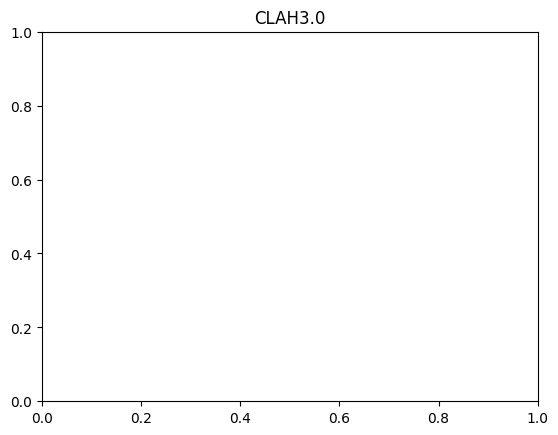

In [80]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'HAFIZ RIZQI HERNANDA'
NIM = '244107020154'
N = int(NIM[-3:])

PARAM = {
    'bipins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s : %s' % (k, v))

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

plt.title('CLAH' + str(PARAM['clip']))

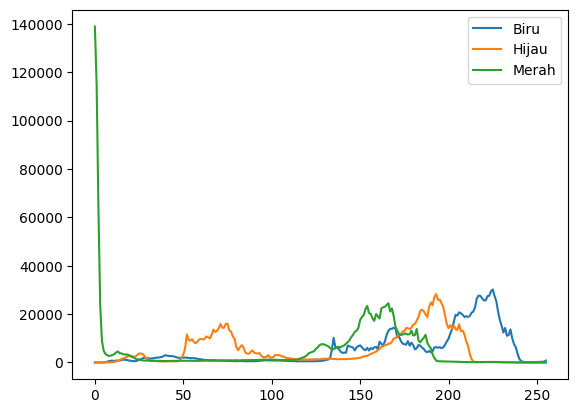

In [21]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/PCVK/'
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)  # 1. siapkan penghitung, isi 0

    for y in range(img.shape[0]):    # 2. telusuri setiap baris
        for x in range(img.shape[1]): # 2. dan setiap kolom
            h[img[y, x]] += 1        # 3. tambah 1 sesuai nilai piksel

    return h


gray = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

h = histogram_manual(gray)
p = h / gray.size                  # 4. normalisasi, jumlahnya = 1
cdf = p.cumsum()                   # 5. distribusi kumulatif

assert h.sum() == gray.size        # pemeriksaan wajib

# citra berwarna: ulangi untuk tiap kanal
bgr = cv.imread(BASE + '/KTM1d.jpeg')

for i, nama in enumerate(['Biru', 'Hijau', 'Merah']):
    plt.plot(histogram_manual(bgr[:, :, i]), label=nama)
    plt.legend()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


<BarContainer object of 256 artists>

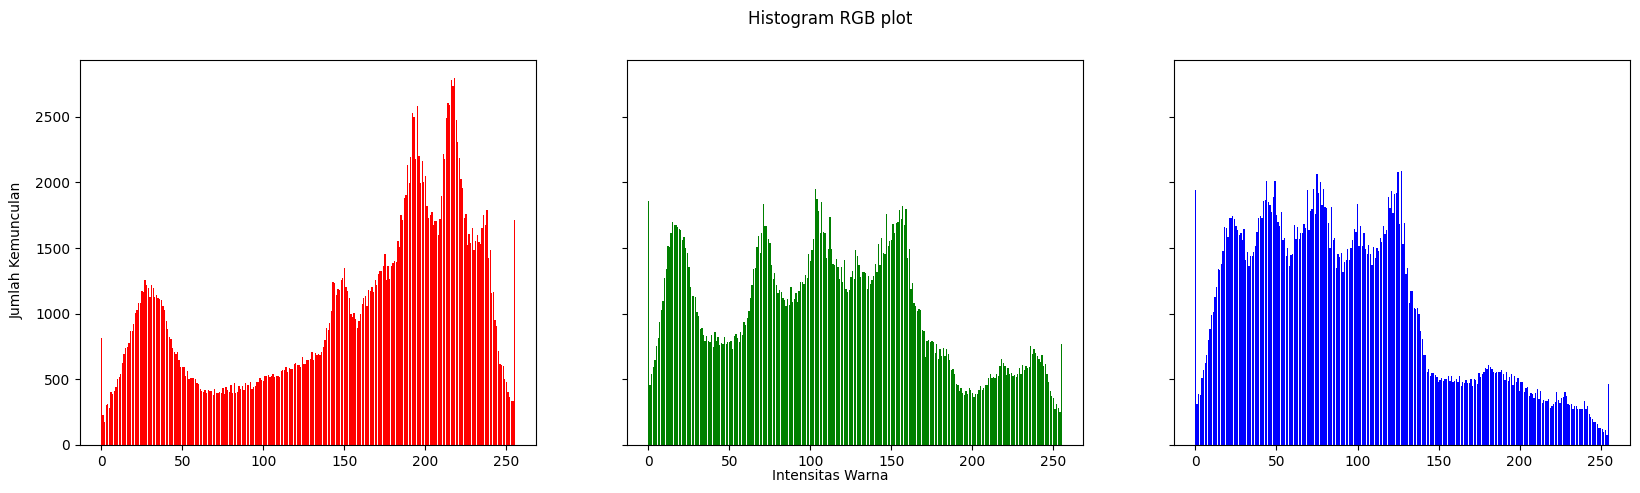

In [15]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
    for x in range(0,width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


<BarContainer object of 256 artists>

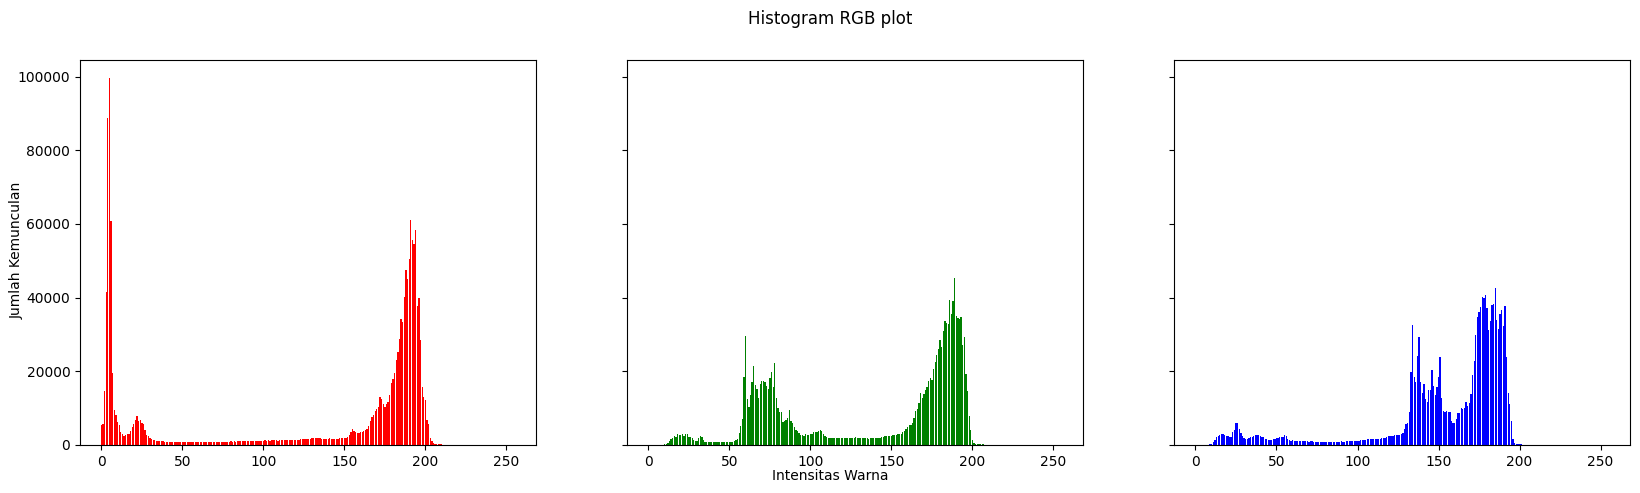

In [14]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
    for x in range(0,width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

Pertanyaan No.1 Pada Praktikum E1

In [7]:
#Membuat Fungsi Histogram Manual
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [10]:
# Membaca gambar Lena
CONTOH = '/content/drive/MyDrive/'
gray = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)

In [11]:
h = histogram_manual(gray)

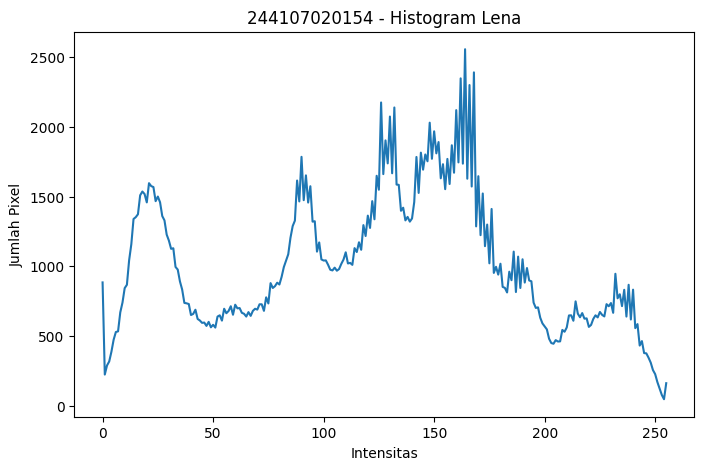

In [12]:
plt.figure(figsize=(8,5))
plt.plot(h)
plt.title(NIM + ' - Histogram Lena')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.show()

In [18]:
#Membuat Fungsi Histogram Manual
def histogram_manual(img, L=256):
    h_ktm = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h_ktm[img[y, x]] += 1

    return h_ktm

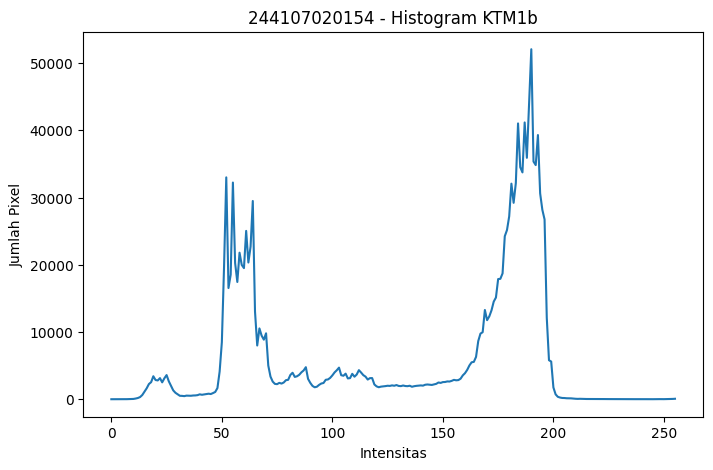

In [22]:
# Menggunakan Gambar KTM1b
gray_ktm = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

h_ktm = histogram_manual(gray_ktm)

plt.figure(figsize=(8,5))
plt.plot(h_ktm)
plt.title(NIM + ' - Histogram KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.show()

Membandingkan histogram manual, NumPy, dan cv.calcHist pada Lena

In [23]:
h_manual = histogram_manual(gray)

In [24]:
h_numpy, edges = np.histogram(gray, bins=256, range=(0,256))

In [25]:
h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).ravel()

In [26]:
print("Selisih manual vs numpy :", np.max(np.abs(h_manual - h_numpy)))
print("Selisih manual vs cv    :", np.max(np.abs(h_manual - h_cv)))
print("Selisih numpy vs cv     :", np.max(np.abs(h_numpy - h_cv)))

Selisih manual vs numpy : 0
Selisih manual vs cv    : 0.0
Selisih numpy vs cv     : 0.0


Membandingkan histogram manual, NumPy, dan cv.calcHist pada KTM1b

In [27]:
h_ktm_Manual = histogram_manual(gray_ktm)

In [28]:
h_ktm_numpy, edges = np.histogram(gray_ktm, bins=256, range=(0,256))

In [29]:
h_ktm_cv = cv.calcHist([gray_ktm], [0], None, [256], [0,256]).ravel()

In [30]:
print("Selisih manual vs numpy :", np.max(np.abs(h_ktm_Manual - h_ktm_numpy)))
print("Selisih manual vs cv    :", np.max(np.abs(h_ktm_Manual - h_ktm_cv)))
print("Selisih numpy vs cv     :", np.max(np.abs(h_ktm_numpy - h_ktm_cv)))

Selisih manual vs numpy : 0
Selisih manual vs cv    : 0.0
Selisih numpy vs cv     : 0.0


Pertanyaan No.2 Pada Praktikum E1

In [33]:
# Buat daftar File
files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']

In [34]:
# Baca masing-masing citra grayscale
images = []

for f in files:
    img = cv.imread(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    images.append(img)

In [35]:
# Hitung histogram
h = histogram_manual(img)
# Normalisasi Histogram
p = h / img.size
# Hitung CDF
cdf = np.cumsum(p)


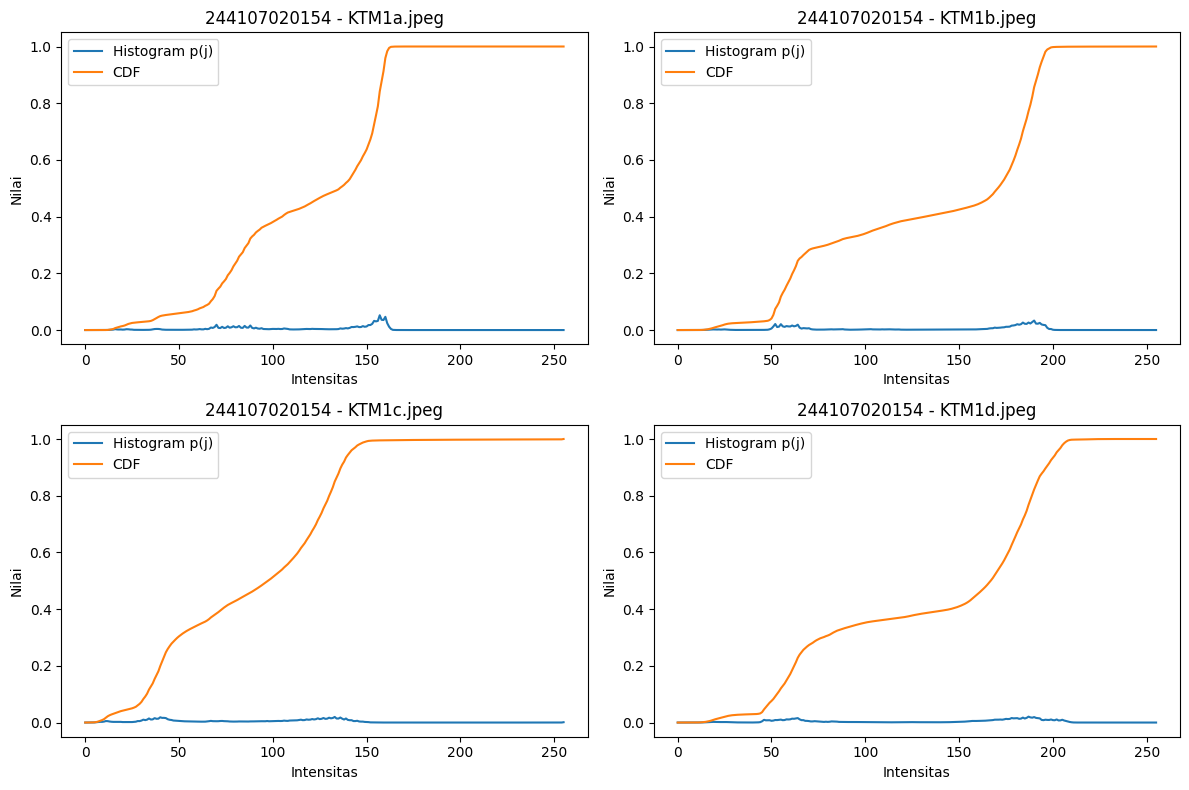

In [36]:
# Buat figure 2x2
plt.figure(figsize=(12,8))

for i, (img, f) in enumerate(zip(images, files), 1):
    h = histogram_manual(img)
    p = h / img.size
    cdf = np.cumsum(p)

    plt.subplot(2,2,i)
    plt.plot(np.arange(256), p, label='Histogram p(j)')
    plt.plot(np.arange(256), cdf, label='CDF')
    plt.title(NIM + ' - ' + f)
    plt.xlabel('Intensitas')
    plt.ylabel('Nilai')
    plt.legend()

plt.tight_layout()
plt.show()

Pertanyaan No.3 Pada Praktikum E1

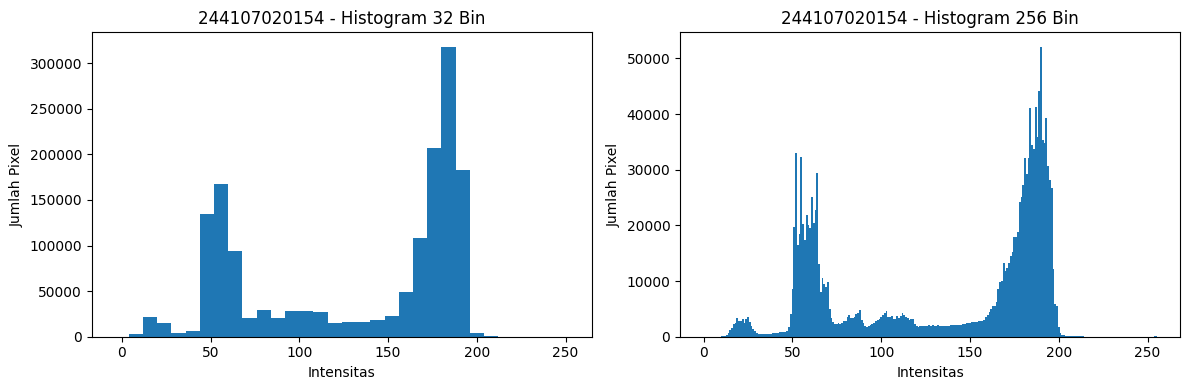

In [41]:
img = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

PARAM = {
    'bins': 32   # jumlah bin
}
# Histogram 32 bin
hist32, edge32 = np.histogram(
    img,
    bins=PARAM['bins'],
    range=(0,256)
)
# Histogram 256 bin
hist256, edge256 = np.histogram(
    img,
    bins=256,
    range=(0,256)
)
# Menampilkan
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(edge32[:-1], hist32, width=8)
plt.title(NIM + ' - Histogram 32 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1,2,2)
plt.bar(edge256[:-1], hist256, width=1)
plt.title(NIM + ' - Histogram 256 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

PERCOBAAN PRAKTIKUM E2

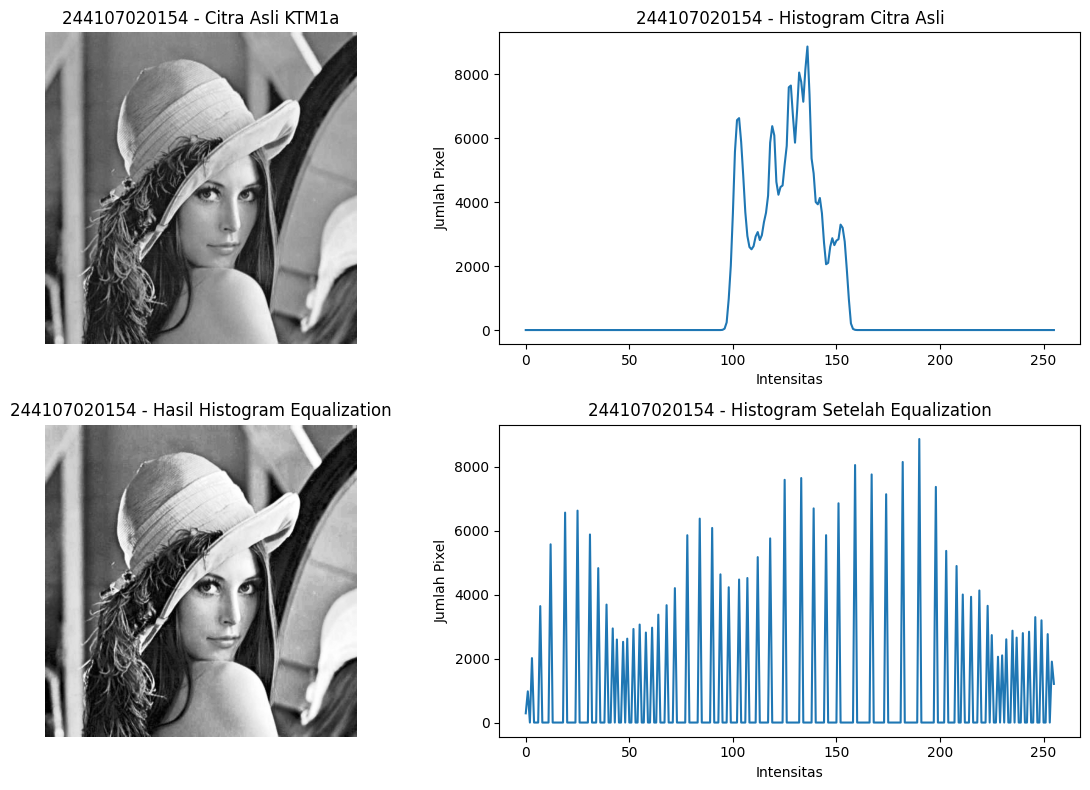

In [48]:
# NOMOR 1
# Tahap 1
img = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
hist = histogram_manual(img)
prob = hist / img.size
cdf = np.cumsum(prob)

L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)
hasil_manual = transform[img]

hist_asli = cv.calcHist(
    [img], [0], None, [256], [0, 256]
)
hist_equal = cv.calcHist(
    [hasil_manual], [0], None, [256], [0, 256]
)
plt.figure(figsize=(12, 8))
# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli KTM1a')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 2)
plt.plot(hist_asli)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Citra hasil equalization
plt.subplot(2, 2, 3)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - Hasil Histogram Equalization')
plt.axis('off')

# Histogram hasil equalization
plt.subplot(2, 2, 4)
plt.plot(hist_equal)
plt.title(NIM + ' - Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

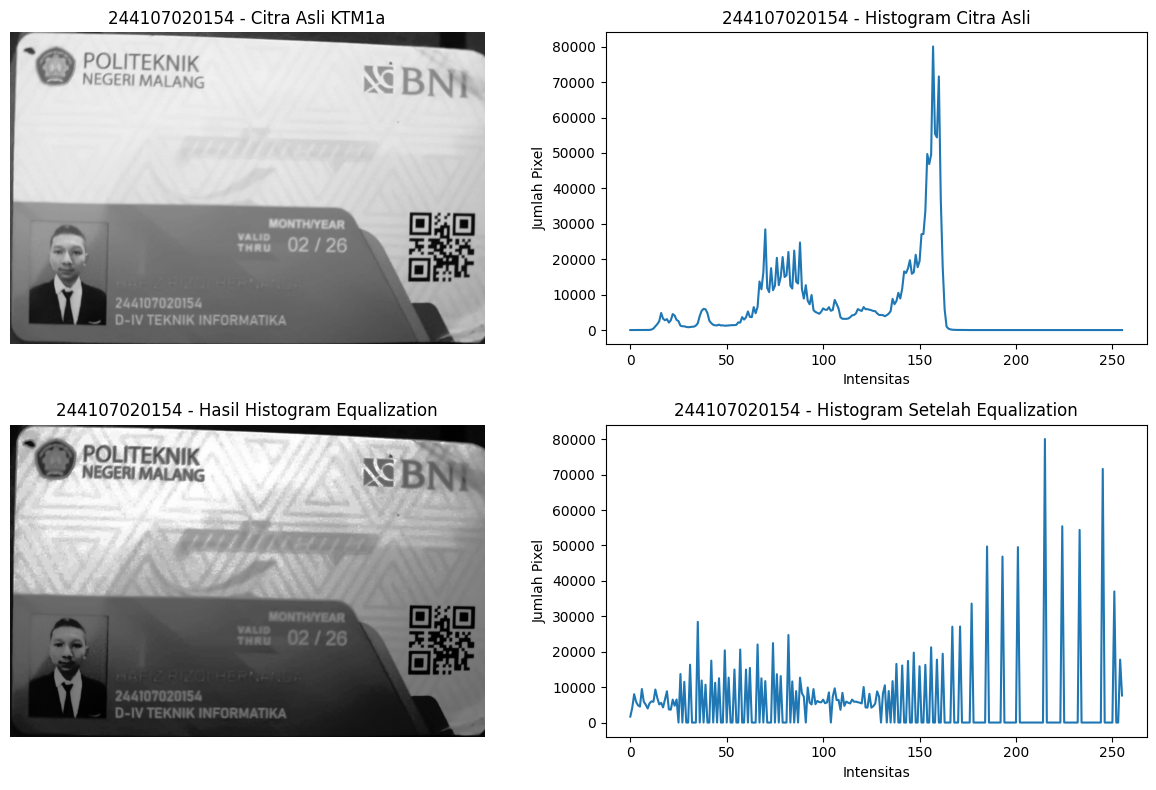

In [49]:
img = cv.imread(BASE + '/KTM1a.jpeg', cv.IMREAD_GRAYSCALE)
hist = histogram_manual(img)
prob = hist / img.size
cdf = np.cumsum(prob)

L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)
hasil_manual = transform[img]

hist_asli = cv.calcHist(
    [img], [0], None, [256], [0, 256]
)
hist_equal = cv.calcHist(
    [hasil_manual], [0], None, [256], [0, 256]
)
plt.figure(figsize=(12, 8))
# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli KTM1a')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 2)
plt.plot(hist_asli)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Citra hasil equalization
plt.subplot(2, 2, 3)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - Hasil Histogram Equalization')
plt.axis('off')

# Histogram hasil equalization
plt.subplot(2, 2, 4)
plt.plot(hist_equal)
plt.title(NIM + ' - Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

# Nomor 2

Selisih maksimum Lena LC: 0
Selisih maksimum KTM1a: 0


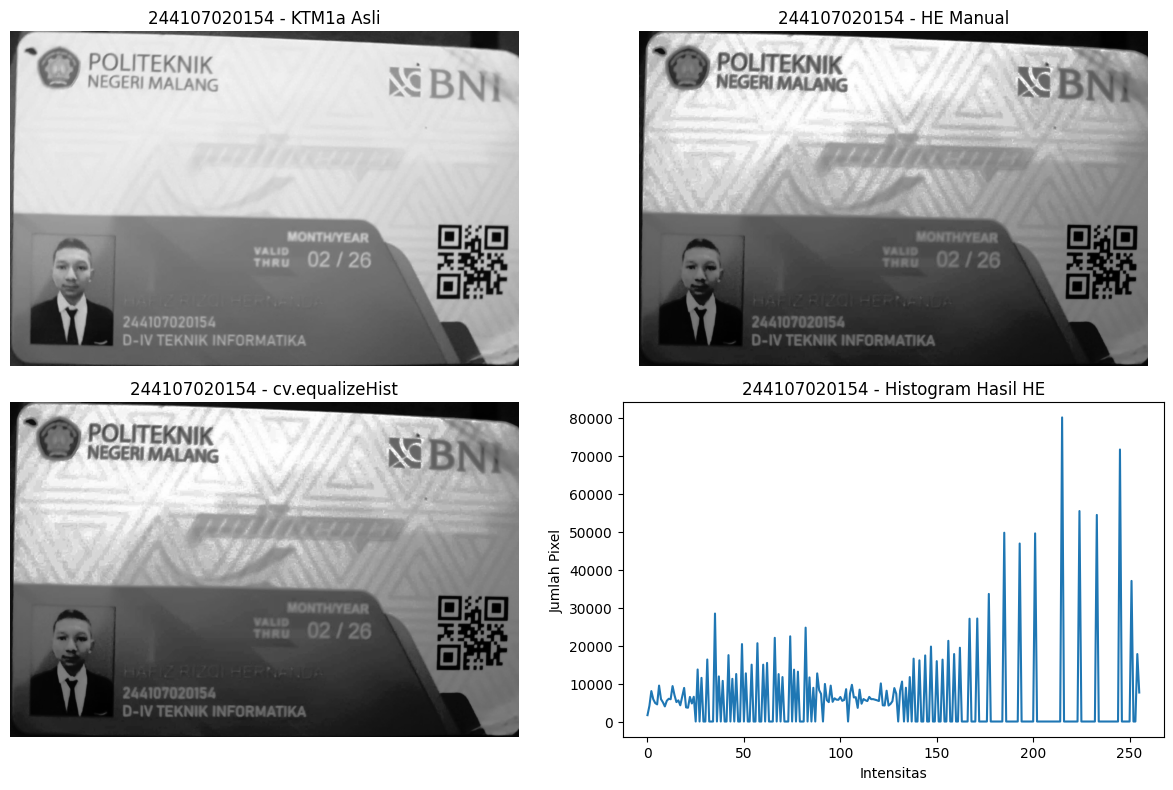

In [50]:
# E-2 NOMOR 2
# Perbandingan HE Manual vs cv.equalizeHist

def histogram_equalization_manual(img):
    hist = histogram_manual(img)

    prob = hist / img.size

    cdf = np.cumsum(prob)

    L = 256

    transform = np.round(
        (L - 1) * cdf
    ).astype(np.uint8)

    hasil = transform[img]

    return hasil

# TAHAP 1 - LENA_LC

img_lena = cv.imread(
    CONTOH + '/lena_lc.jpg',
    cv.IMREAD_GRAYSCALE
)

hasil_manual_lena = histogram_equalization_manual(img_lena)
hasil_cv_lena = cv.equalizeHist(img_lena)

selisih_lena = np.max(
    np.abs(
        hasil_manual_lena.astype(np.int16) -
        hasil_cv_lena.astype(np.int16)
    )
)

print("Selisih maksimum Lena LC:",
      selisih_lena)

# TAHAP 2 - KTM1A

img_ktm = cv.imread(
    BASE + '/KTM1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

hasil_manual_ktm = histogram_equalization_manual(img_ktm)
hasil_cv_ktm = cv.equalizeHist(img_ktm)

selisih_ktm = np.max(
    np.abs(
        hasil_manual_ktm.astype(np.int16) -
        hasil_cv_ktm.astype(np.int16)
    )
)

print("Selisih maksimum KTM1a:",
      selisih_ktm)

# TAMPILKAN HASIL KTM1A

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_ktm, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(hasil_manual_ktm, cmap='gray')
plt.title(NIM + ' - HE Manual')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(hasil_cv_ktm, cmap='gray')
plt.title(NIM + ' - cv.equalizeHist')
plt.axis('off')

plt.subplot(2,2,4)
plt.plot(
    cv.calcHist(
        [hasil_cv_ktm],
        [0],
        None,
        [256],
        [0,256]
    )
)
plt.title(NIM + ' - Histogram Hasil HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [51]:
# Nomor 3
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
berkas = CONTOH + '/lena.jpg' # tahap 1; tahap 2 ganti: BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
 kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

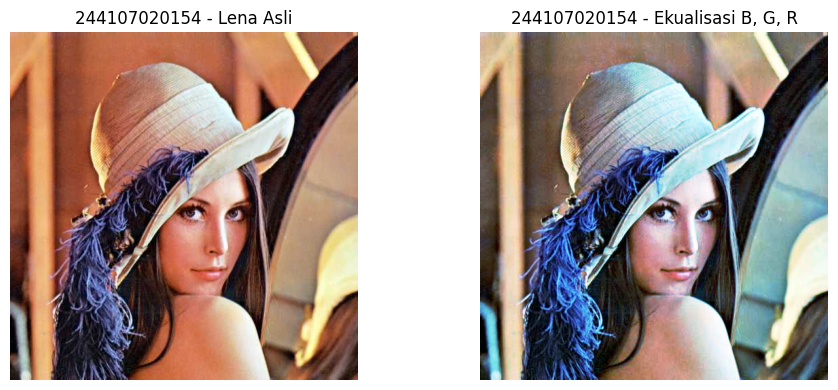

In [53]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lena Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R')
plt.axis('off')

plt.tight_layout()
plt.show()

In [57]:
berkas1 = BASE + '/KTM1d.jpeg' #BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas1)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
 kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

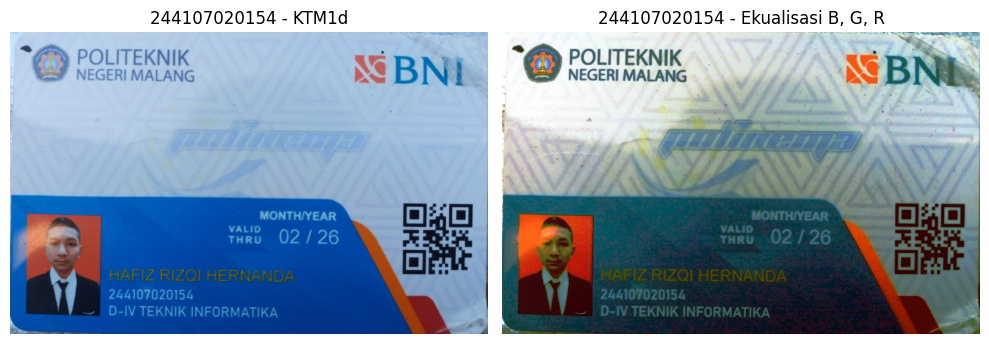

In [59]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R')
plt.axis('off')

plt.tight_layout()
plt.show()

In [60]:
# Nomor 3
# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

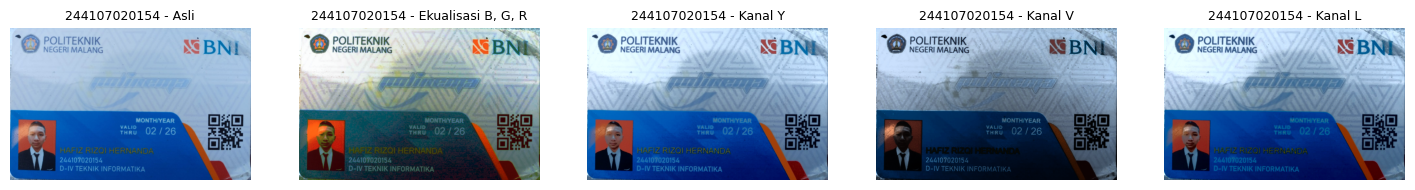

In [61]:
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
 plt.subplot(1, 5, i)
 plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
 plt.title(NIM + ' - ' + t, fontsize=9)
 plt.axis('off')
plt.show()

In [62]:
def geser_hue(asli, hasil):
 h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
 h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
 d = np.abs(h1 - h2)
 d = np.minimum(d, 180 - d) # Hue melingkar 0-179
 return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
 print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
 cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            136.6
Ekualisasi B, G, R                44.83            125.3
Kanal Y                            3.22            129.7
Kanal V                            0.77            100.1
Kanal L                            4.33            120.4


Pertanyaan Praktikum E2

Poin A

In [68]:
# Membaca KTM1a dalam grayscale
img = cv.imread(BASE + '/KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

# Histogram Equalization manual
hist = histogram_manual(img)
prob = hist / img.size
cdf = np.cumsum(prob)

L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)

hasil_manual = transform[img]

# Histogram Equalization menggunakan OpenCV
hasil_cv = cv.equalizeHist(img)

In [69]:
selisih = np.max(
    np.abs(
        hasil_manual.astype(np.int16) -
        hasil_cv.astype(np.int16)
    )
)

print("Selisih maksimum:", selisih)

Selisih maksimum: 0


Poin B

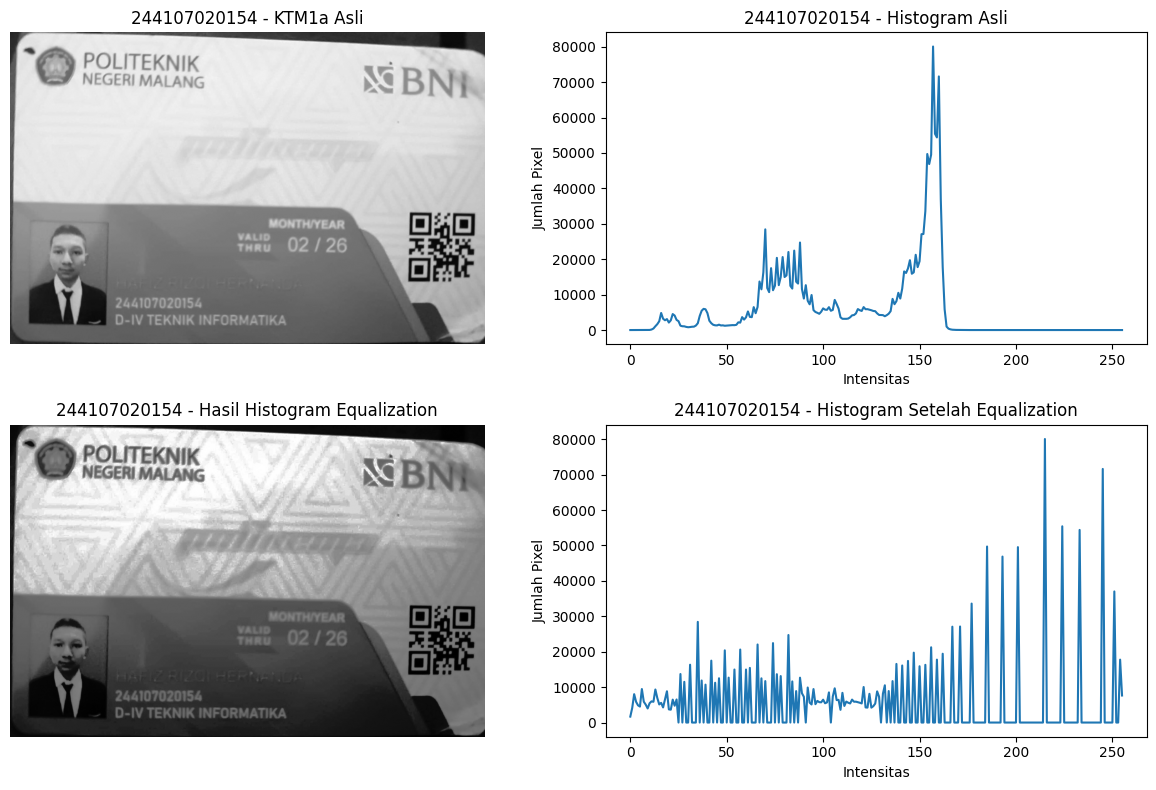

In [70]:
hist_asli = cv.calcHist([img], [0], None, [256], [0,256])
hist_hasil = cv.calcHist([hasil_cv], [0], None, [256], [0,256])

plt.figure(figsize=(12,8))

# Citra asli
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

# Histogram asli
plt.subplot(2,2,2)
plt.plot(hist_asli)
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Citra hasil equalization
plt.subplot(2,2,3)
plt.imshow(hasil_cv, cmap='gray')
plt.title(NIM + ' - Hasil Histogram Equalization')
plt.axis('off')

# Histogram hasil equalization
plt.subplot(2,2,4)
plt.plot(hist_hasil)
plt.title(NIM + ' - Histogram Setelah Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

Poin C

In [71]:
# C
mse = np.mean(
    (img.astype(np.float32) -
     hasil_cv.astype(np.float32)) ** 2
)

psnr = 10 * np.log10(
    (255 ** 2) / mse
)

print("MSE :", mse)
print("PSNR:", psnr, "dB")

MSE : 1612.8262
PSNR: 16.054928 dB


Nomor 2

A

In [76]:
clahe = cv.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(4,4)
)
hasil_clahe = clahe.apply(img)

In [81]:
NIM = '244107020154'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

print(PARAM)

{'bins': 32, 'clip': 3.0, 'tile': 4, 'L': 4}


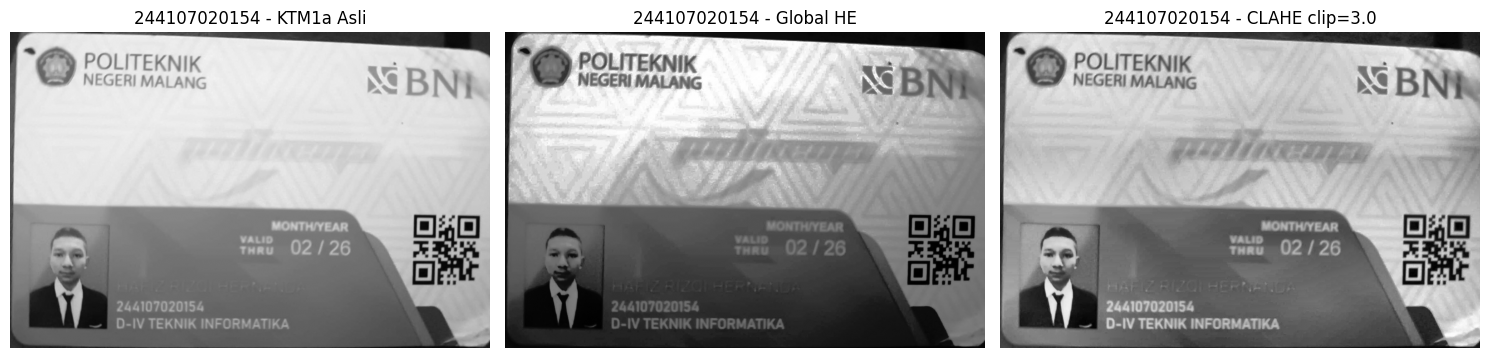

In [82]:
img = cv.imread(
    BASE + '/KTM1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

global_he = cv.equalizeHist(img)

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

hasil_clahe = clahe.apply(img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(global_he, cmap='gray')
plt.title(NIM + ' - Global HE')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_clahe, cmap='gray')
plt.title(NIM + ' - CLAHE clip=3.0')
plt.axis('off')

plt.tight_layout()
plt.show()

Poin B

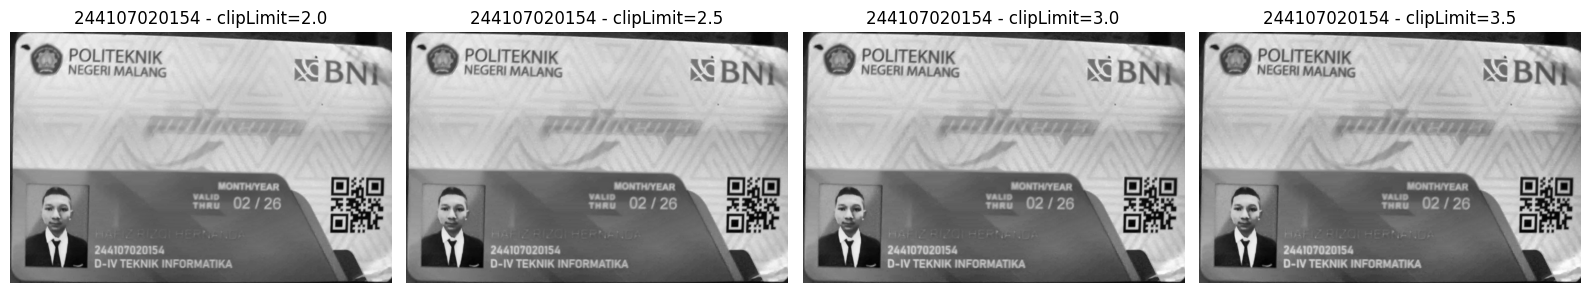

In [83]:
clip_values = [2.0, 2.5, 3.0, 3.5]

plt.figure(figsize=(16,4))

for i, clip in enumerate(clip_values, 1):

    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(4,4)
    )

    hasil = clahe.apply(img)

    plt.subplot(1,4,i)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + f' - clipLimit={clip}')
    plt.axis('off')

plt.tight_layout()
plt.show()

E3 - Tugas

Nomor 1

In [84]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()

    step = 255.0 / (L - 1)

    H, W = img.shape

    for y in range(H):
        for x in range(W):

            lama = img[y, x]

            baru = np.round(lama / step) * step

            img[y, x] = baru

            error = lama - baru

            # kanan
            if x + 1 < W:
                img[y, x+1] += error * 7 / 16

            # bawah-kiri
            if x > 0 and y + 1 < H:
                img[y+1, x-1] += error * 3 / 16

            # bawah
            if y + 1 < H:
                img[y+1, x] += error * 5 / 16

            # bawah-kanan
            if x + 1 < W and y + 1 < H:
                img[y+1, x+1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

In [85]:
def dithering_color(bgr, L=2):
    b, g, r = cv.split(bgr)

    b_d = floyd_steinberg(b, L)
    g_d = floyd_steinberg(g, L)
    r_d = floyd_steinberg(r, L)

    return cv.merge([b_d, g_d, r_d])

In [86]:
lena = cv.imread(
    CONTOH + '/lena.jpg'
)
print(lena.shape)

(512, 512, 3)


In [87]:
lena_dither = dithering_color(
    lena,
    L=PARAM['L']
)

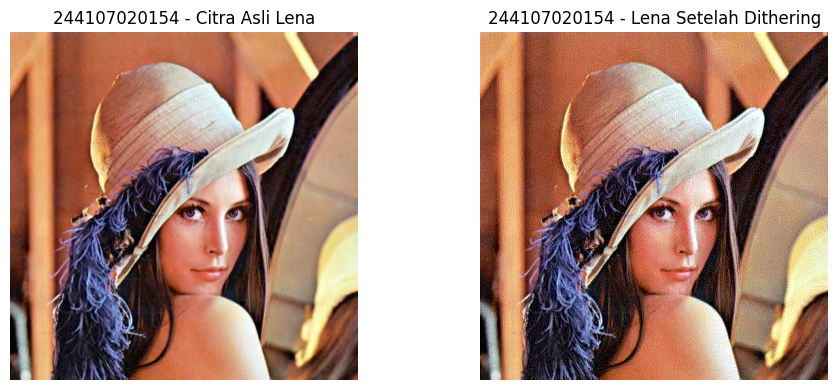

In [88]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(lena, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra Asli Lena')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lena Setelah Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

In [89]:
ktm = cv.imread(
    BASE + '/KTM1b.jpeg'
)
print(ktm.shape)

(1003, 1552, 3)


In [90]:
ktm_dither = dithering_color(
    ktm,
    L=PARAM['L']
)

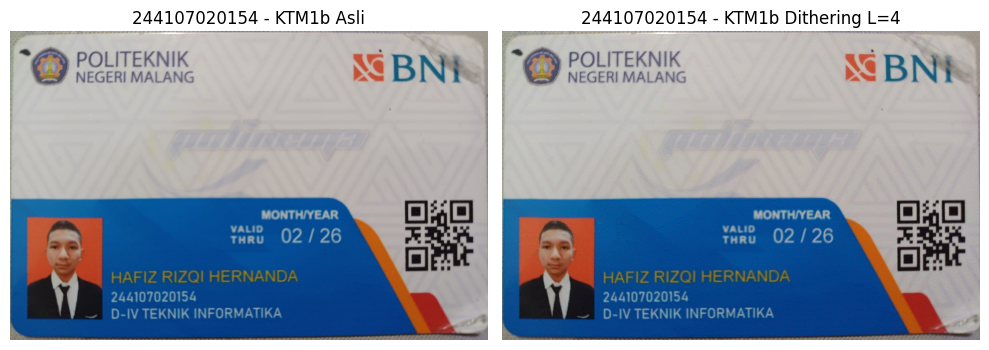

In [91]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(ktm, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(ktm_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Dithering L=4')
plt.axis('off')

plt.tight_layout()
plt.show()

Nomor 2

In [92]:
lena_lc = cv.imread(
    CONTOH + '/lena_lc.jpg',
    cv.IMREAD_GRAYSCALE
)
print(lena_lc.shape)

(512, 512)


In [93]:
dither_langsung_lena = floyd_steinberg(
    lena_lc,
    L=PARAM['L']
)

In [94]:
he_lena = cv.equalizeHist(lena_lc)

In [95]:
dither_he_lena = floyd_steinberg(
    he_lena,
    L=PARAM['L']
)

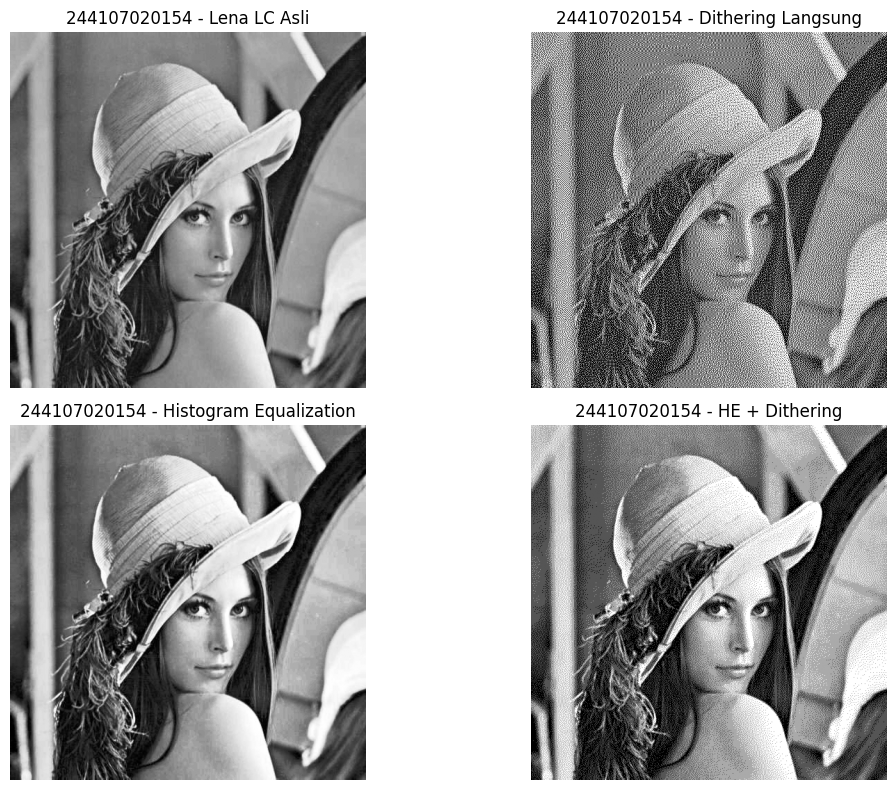

In [96]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(lena_lc, cmap='gray')
plt.title(NIM + ' - Lena LC Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(dither_langsung_lena, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(he_lena, cmap='gray')
plt.title(NIM + ' - Histogram Equalization')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(dither_he_lena, cmap='gray')
plt.title(NIM + ' - HE + Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

Tahap 2

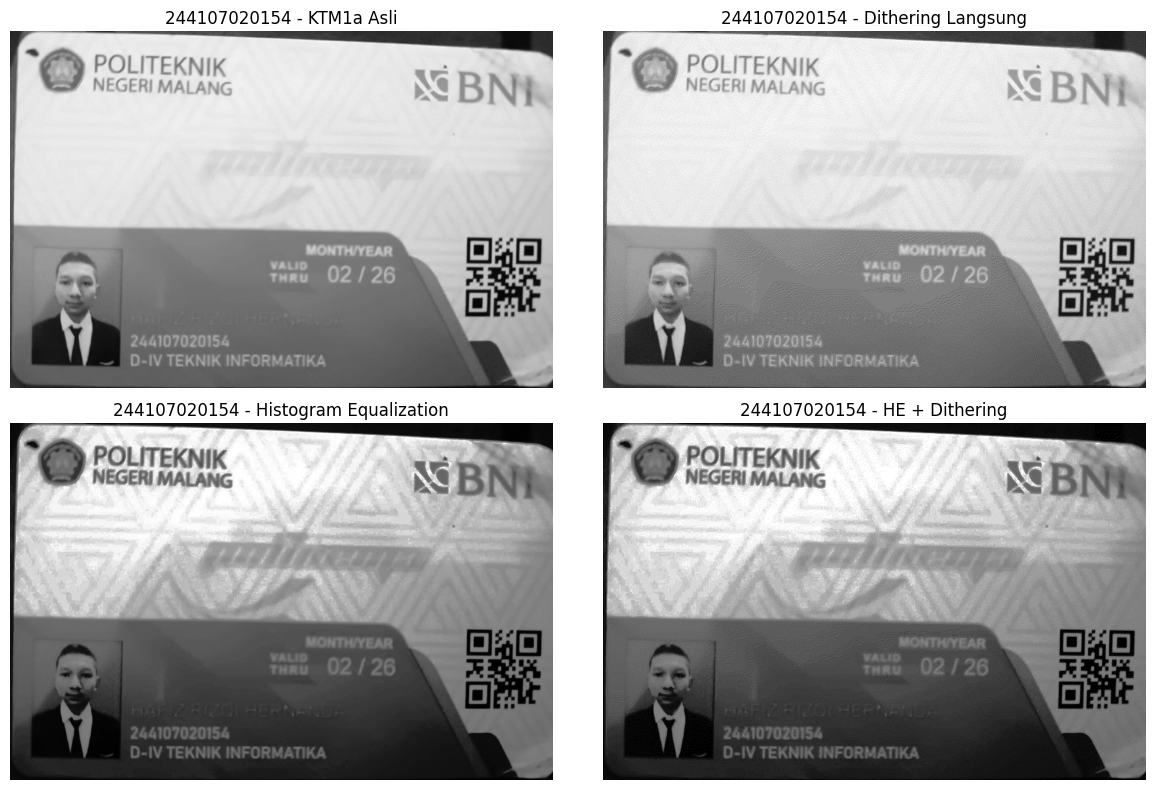

In [103]:
ktm1a = cv.imread(
    BASE + '/KTM1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

# Dithering langsung
dither_langsung_ktm = floyd_steinberg(
    ktm1a,
    L=PARAM['L']
)

# Histogram Equalization
he_ktm = cv.equalizeHist(ktm1a)

# HE + Dithering
dither_he_ktm = floyd_steinberg(
    he_ktm,
    L=PARAM['L']
)

# Tampilkan KTM
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(dither_langsung_ktm, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(he_ktm, cmap='gray')
plt.title(NIM + ' - Histogram Equalization')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(dither_he_ktm, cmap='gray')
plt.title(NIM + ' - HE + Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()